In [11]:
import os
notebookPath = os.path.dirname(os.path.dirname(os.getcwd()))

In [12]:
notebookPath

'c:\\Users\\IOC\\OneDrive - FIOCRUZ\\Área de Trabalho\\analysis'

In [13]:
import scanpy as sc
output_dir = os.path.join(notebookPath, "data", "filtered_h5ad")
pastas = sorted(os.listdir(output_dir))

adatas = [sc.read_h5ad(os.path.join(output_dir, pastas[i])) for i in range(len(pastas))]

In [14]:
for adata in adatas:
    adata.var_names_make_unique()
    adata.obs_names_make_unique()

     dataset  n_cells  n_genes  total_reads  mean_reads_per_cell  \
0   CTH92_ML     1527    24293    7929813.0          5193.066895   
1   CTH92_NS      812    24397    8358896.0         10294.207031   
2   CTH94_ML      499    23630    6091147.0         12206.707031   
3   CTH94_NS     5558    29426   50007112.0          8997.321289   
4   CTH97_ML     4657    24340   15101780.0          3242.812988   
5   CTH97_NS     1506    26012   13468904.0          8943.495117   
6   HNP44_ML     1862    28391   27347608.0         14687.222656   
7   HNP44_NS       88    21811    1839723.0         20905.943359   
8    MB34_ML      921    24478   11543259.0         12533.397461   
9    MB34_NS     1911    28373   26863936.0         14057.528320   
10   PB20_ML      777    25107    8816715.0         11347.124023   
11   PB20_NS      606    24038    6077546.0         10028.954102   
12   PB21_ML    10619    29354   78930448.0          7432.945312   
13   PB21_NS     3626    27795   32991122.0     

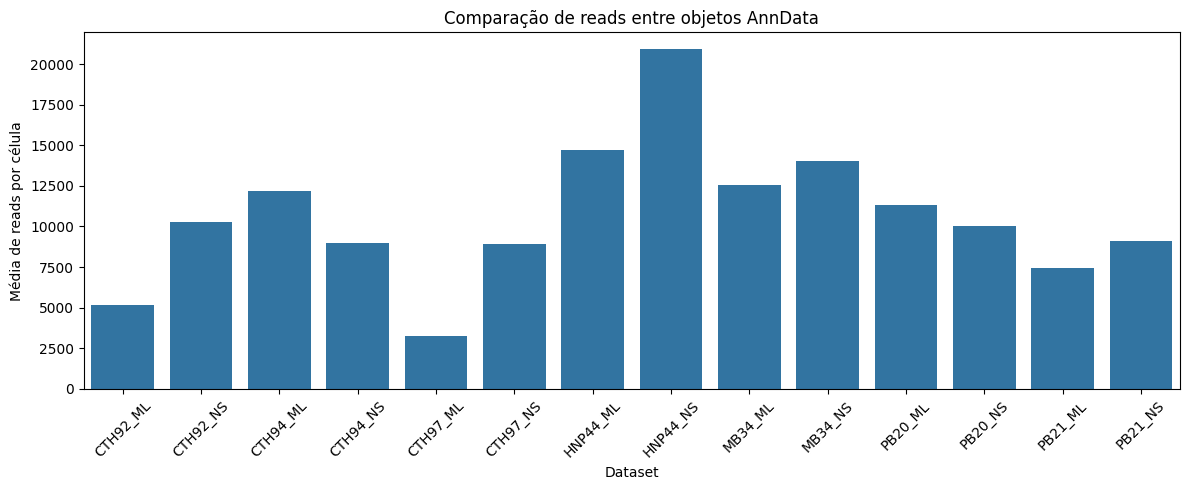

In [20]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# Lista contendo os 14 objetos AnnData
# adatas = [adata1, adata2, ..., adata14]

# -----------------------------
# Resumo de reads por objeto
# -----------------------------

summary = []

for i, adata in enumerate(adatas):
    
    # Número total de reads por célula
    total_reads_per_cell = np.array(adata.X.sum(axis=1)).flatten()
    
    # Número total de reads no objeto
    total_reads = total_reads_per_cell.sum()
    
    # Estatísticas
    summary.append({
        "dataset": f"{pastas[i].split('.')[0]}",
        "n_cells": adata.n_obs,
        "n_genes": adata.n_vars,
        "total_reads": total_reads,
        "mean_reads_per_cell": total_reads_per_cell.mean(),
        "median_reads_per_cell": np.median(total_reads_per_cell),
        "min_reads_per_cell": total_reads_per_cell.min(),
        "max_reads_per_cell": total_reads_per_cell.max()
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

# -----------------------------
# Visualização
# -----------------------------

plt.figure(figsize=(12,5))

sns.barplot(
    data=summary_df,
    x="dataset",
    y="mean_reads_per_cell"
)

plt.xticks(rotation=45)
plt.ylabel("Média de reads por célula")
plt.xlabel("Dataset")
plt.title("Comparação de reads entre objetos AnnData")

plt.tight_layout()
plt.show()

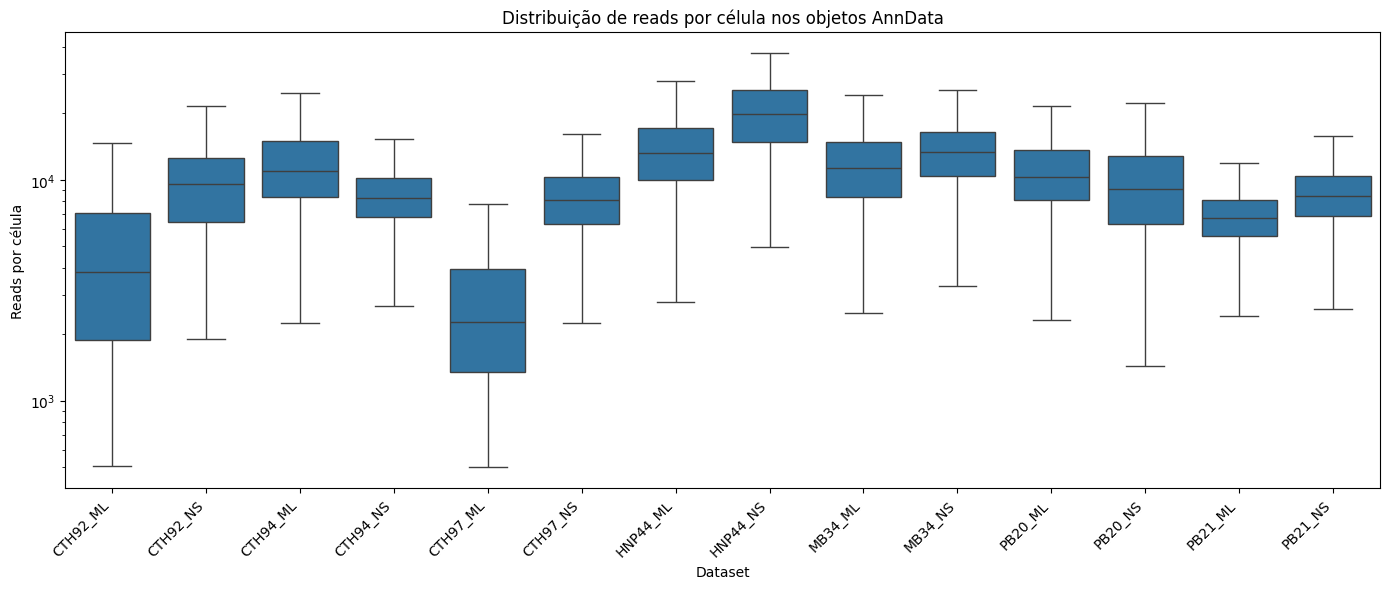

In [21]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Preparar dados para boxplot
# -----------------------------

boxplot_data = []

for i, adata in enumerate(adatas):
    
    # Reads totais por célula
    total_reads_per_cell = np.array(adata.X.sum(axis=1)).flatten()
    
    # Criar dataframe temporário
    temp_df = pd.DataFrame({
        "dataset": f"{pastas[i].split('.')[0]}",
        "reads_per_cell": total_reads_per_cell
    })
    
    boxplot_data.append(temp_df)

# Concatenar todos os datasets
boxplot_df = pd.concat(boxplot_data, ignore_index=True)

# -----------------------------
# Boxplot
# -----------------------------

plt.figure(figsize=(14,6))

sns.boxplot(
    data=boxplot_df,
    x="dataset",
    y="reads_per_cell",
    showfliers=False  # remove outliers extremos do gráfico
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Reads por célula")
plt.xlabel("Dataset")
plt.title("Distribuição de reads por célula nos objetos AnnData")

# Opcional: escala log
plt.yscale("log")

plt.tight_layout()
plt.show()

In [23]:
print(f"ENSG genes: {len([i for i in adata.var['gene_symbols'] if i.startswith('ENSG')])}")
print(f"Symbol genes: {len([i for i in adata.var['gene_symbols'] if not i.startswith('ENSG')])}")
print(f"Total genes: {len([i for i in adata.var['gene_symbols']])}")

ENSG genes: 7275
Symbol genes: 20520
Total genes: 27795


In [24]:
import anndata as an
bdata = an.concat(adatas[0:], join="inner", fill_value = 0, uns_merge="first", label= "library_id", keys= [i.replace(".h5ad", "") for i in pastas])
bdata.obs_names_make_unique()

c:\Users\IOC\OneDrive - FIOCRUZ\Área de Trabalho\analysis\.venv\Lib\site-packages\anndata\_core\anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [25]:
bdata

AnnData object with n_obs × n_vars = 34969 × 17761
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'mt_outlier', 'library_id'
    uns: 'preprocessing_stats_CTH92_ML', 'preprocessing_stats_CTH92_NS', 'preprocessing_stats_CTH94_ML', 'preprocessing_stats_CTH94_NS', 'preprocessing_stats_CTH97_ML', 'preprocessing_stats_CTH97_NS', 'preprocessing_stats_HNP44_ML', 'preprocessing_stats_HNP44_NS', 'preprocessing_stats_MB34_ML', 'preprocessing_stats_MB34_NS', 'preprocessing_stats_PB20_ML', 'preprocessing_stats_PB20_NS', 'preprocessing_stats_PB21_ML', 'preprocessing_stats_PB21_NS'

In [28]:
bdata.write_h5ad(os.path.join(notebookPath, "data",  "outputIntegrated", "spatialPaperFiltered.h5ad"))

# Dado Mergido

In [1]:
import scanpy as sc 
import os

notebookPath = os.path.dirname(os.path.dirname(os.getcwd()))

bdata = sc.read(os.path.join(notebookPath, "data", "outputIntegrated", "spatialPaperFiltered.h5ad"))
bdata.obs_names_make_unique()

In [2]:
list(bdata.obs["library_id"].unique())

['CTH92_ML',
 'CTH92_NS',
 'CTH94_ML',
 'CTH94_NS',
 'CTH97_ML',
 'CTH97_NS',
 'HNP44_ML',
 'HNP44_NS',
 'MB34_ML',
 'MB34_NS',
 'PB20_ML',
 'PB20_NS',
 'PB21_ML',
 'PB21_NS']

In [3]:
bdata.obs["controles"] = [
    "controle" if i.startswith("CTH") else "estudo"
    for i in bdata.obs["library_id"]
]

bdata.obs["classificacao"] = [
    "PB" if i.startswith("PB")
    else "controle" if i.startswith("CTH")
    else "MB"
    for i in bdata.obs["library_id"]
]

bdata.obs["estimulo"] = [
    "nao estimulado" if i.endswith("NS") else "estimulado"
    for i in bdata.obs["library_id"]
]

In [4]:
print(bdata.obs["classificacao"].unique())
print(bdata.obs["controles"].unique())
print(bdata.obs["estimulo"].unique())

['controle' 'MB' 'PB']
['controle' 'estudo']
['estimulado' 'nao estimulado']


In [5]:
print('---------------------')
print(bdata.obs["classificacao"].value_counts())
print('---------------------')
print('---------------------')
print(bdata.obs["controles"].value_counts())
print('---------------------')
print('---------------------')
print(bdata.obs["estimulo"].value_counts())
print('---------------------')


---------------------
classificacao
PB          15628
controle    14559
MB           4782
Name: count, dtype: int64
---------------------
---------------------
controles
estudo      20410
controle    14559
Name: count, dtype: int64
---------------------
---------------------
estimulo
estimulado        20862
nao estimulado    14107
Name: count, dtype: int64
---------------------


c:\Users\IOC\OneDrive - FIOCRUZ\Área de Trabalho\analysis\.venv\Lib\site-packages\spatools\plotting\pl.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = adata.obs.groupby([group_by, clusters_col]).size().unstack(fill_value=0)# type: ignore


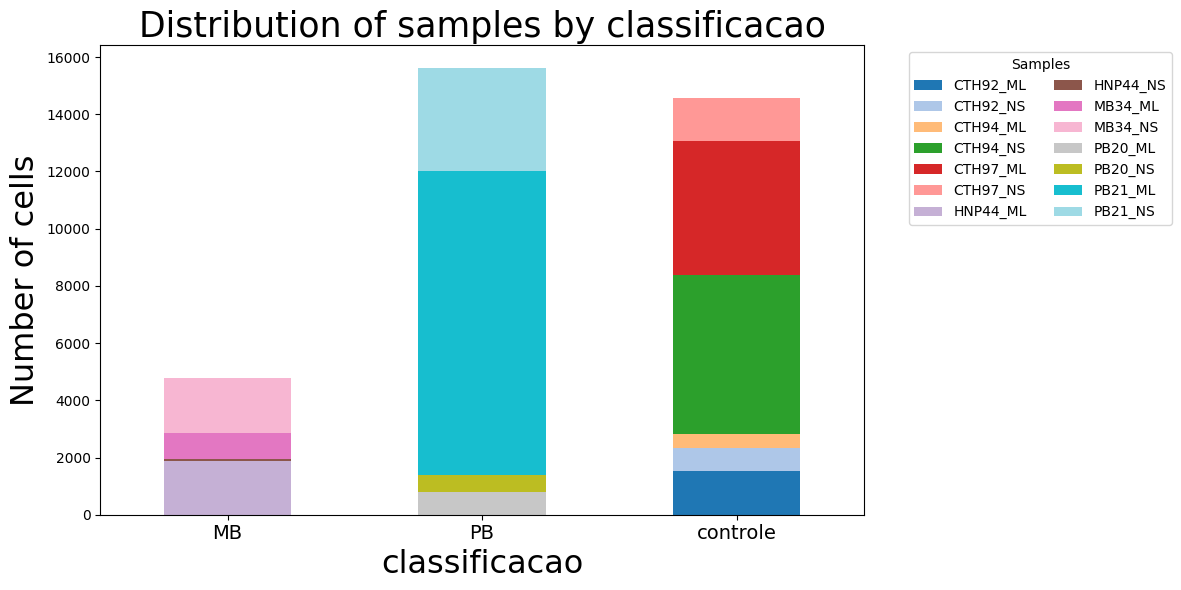

In [6]:
import spatools as st
st.pl.bar(
    adata=bdata,
    clusters_col="library_id",
    group_by="classificacao",
    title="Distribution of samples by classificacao",
    xlabel="classificacao",
    ylabel="Number of cells",
    use_percentage=False, 
    angle=0,
    legend="Samples"
)

c:\Users\IOC\OneDrive - FIOCRUZ\Área de Trabalho\analysis\.venv\Lib\site-packages\spatools\plotting\pl.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = adata.obs.groupby([group_by, clusters_col]).size().unstack(fill_value=0)# type: ignore


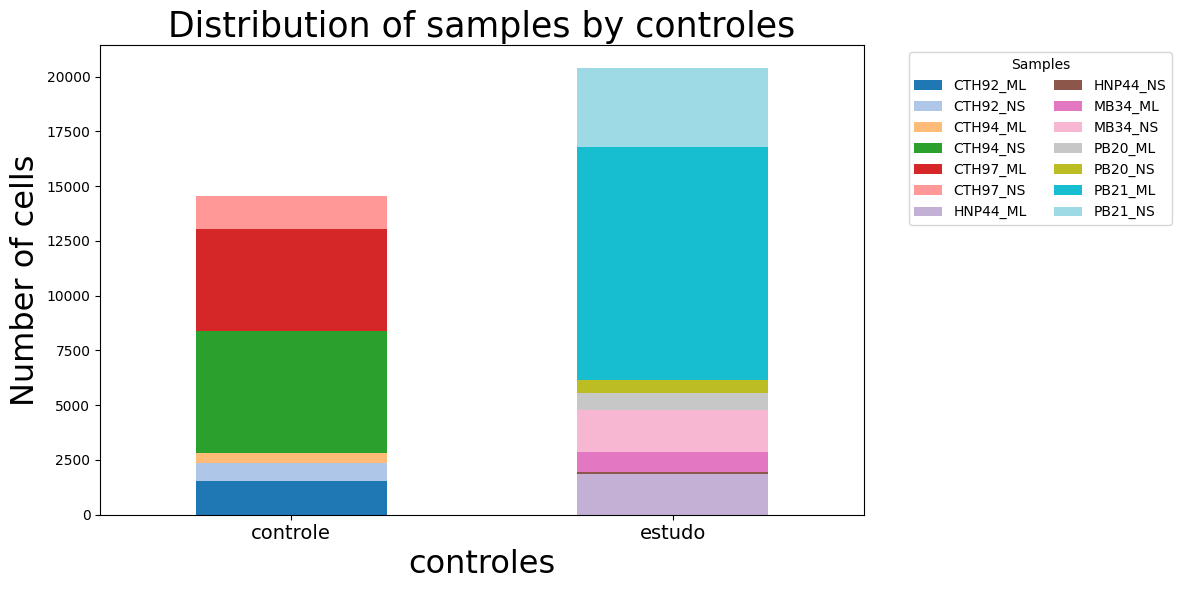

In [7]:
import spatools as st
st.pl.bar(
    adata=bdata,
    clusters_col="library_id",
    group_by="controles",
    title="Distribution of samples by controles",
    xlabel="controles",
    ylabel="Number of cells",
    use_percentage=False, 
    angle=0,
    legend="Samples"
)

c:\Users\IOC\OneDrive - FIOCRUZ\Área de Trabalho\analysis\.venv\Lib\site-packages\spatools\plotting\pl.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = adata.obs.groupby([group_by, clusters_col]).size().unstack(fill_value=0)# type: ignore


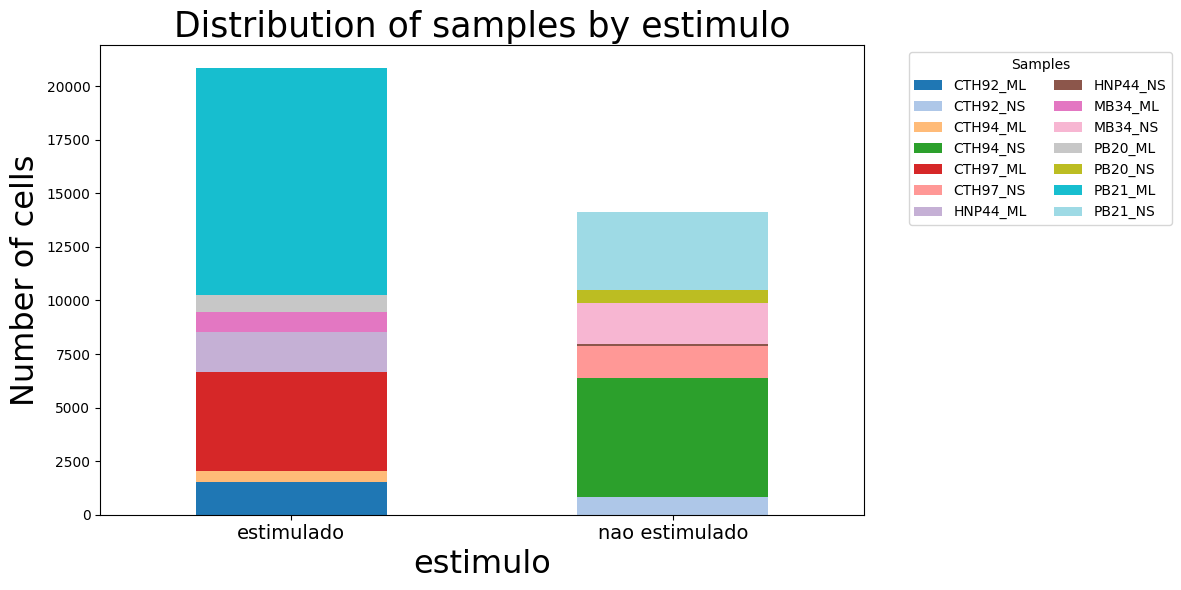

In [8]:
import spatools as st
st.pl.bar(
    adata=bdata,
    clusters_col="library_id",
    group_by="estimulo",
    title="Distribution of samples by estimulo",
    xlabel="estimulo",
    ylabel="Number of cells",
    use_percentage=False, 
    angle=0,
    legend="Samples"
)

# comecando a integracao

In [9]:
from copy import deepcopy
bdata.layers["counts"] = deepcopy(bdata.X)

In [10]:
len([i for i in bdata.var_names if i.startswith('ENSG')])

17761

In [11]:
bdata.var_names_make_unique()
bdata.obs_names_make_unique()

In [12]:
bdata = st.tl.translate_anndata_genes(adata=bdata)

10 input query terms found dup hits:	[('ENSG00000291072', 2), ('ENSG00000234162', 2), ('ENSG00000227110', 2), ('ENSG00000243620', 2), ('E
214 input query terms found no hit:	['ENSG00000238009', 'ENSG00000291215', 'ENSG00000290784', 'ENSG00000236948', 'ENSG00000226849', 'ENS


In [13]:
len([i for i in bdata.var_names if not i.startswith("ENSG")])

15446

In [16]:
bdata.var

,gene_ids,gene_symbol,mt,rps,rpl,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
ENSG00000238009,ENSG00000238009,ENSG00000238009,False,False,False,164,0.004718,0.004707,99.531013,165.0,5.111988
ENSG00000241860,ENSG00000241860,ENSG00000241860,False,False,False,366,0.010781,0.010723,98.953359,377.0,5.934894
ENSG00000290385,ENSG00000290385,ENSG00000290385,False,False,False,230,0.006663,0.006641,99.342275,233.0,5.455321
ENSG00000291215,ENSG00000291215,ENSG00000291215,False,False,False,1085,0.033058,0.032523,96.897252,1156.0,7.053586
LINC01409,ENSG00000237491,LINC01409,False,False,False,2503,0.094226,0.090048,92.842232,3295.0,8.100465
...,...,...,...,...,...,...,...,...,...,...,...
MT-ND6,ENSG00000198695,MT-ND6,True,False,False,12600,0.604507,0.472816,63.968086,21139.0,9.958922
MT-CYB,ENSG00000198727,MT-CYB,True,False,False,33653,29.116560,3.405075,3.763333,1018177.0,13.833526
MAFIP,ENSG00000274847,MAFIP,False,False,False,635,0.019646,0.019455,98.184106,687.0,6.533789
ENSG00000273748,ENSG00000273748,ENSG00000273748,False,False,False,4336,0.208099,0.189048,87.600446,7277.0,8.892612


In [14]:
import scanpy as sc

# genes mitocondriais
bdata.var["mt"] = bdata.var_names.str.startswith("MT-")

# genes ribossomais
bdata.var["rps"] = bdata.var_names.str.startswith("RPS")
bdata.var["rpl"] = bdata.var_names.str.startswith("RPL")

# calcular QC metrics
sc.pp.calculate_qc_metrics(
    bdata,
    qc_vars=["mt", "rps", "rpl"],
    inplace=True
)

In [17]:
sc.experimental.pp.normalize_pearson_residuals(bdata)

# regressão
sc.pp.regress_out(
    bdata,
    keys=[
        "pct_counts_mt",
        "pct_counts_rps",
        "pct_counts_rpl"
    ]
)

# opcional, mais uma garantia
sc.pp.scale(bdata)

c:\Users\IOC\OneDrive - FIOCRUZ\Área de Trabalho\analysis\.venv\Lib\site-packages\scanpy\preprocessing\_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
c:\Users\IOC\OneDrive - FIOCRUZ\Área de Trabalho\analysis\.venv\Lib\site-packages\scanpy\preprocessing\_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


In [ ]:
# len([i for i in bdata.var['rpl'] if i])

In [ ]:
# Agora devo fazer o benchmark do scib com base no meu objeto bdata.
# desejo testar o scVI, harmony, scanorama, BBKNN, scGEN, Seurat v3 3.2.0 CCA (default) and RPCA
# quero que voce de outras opcoes de integracao caso ache cabivel no meu caso